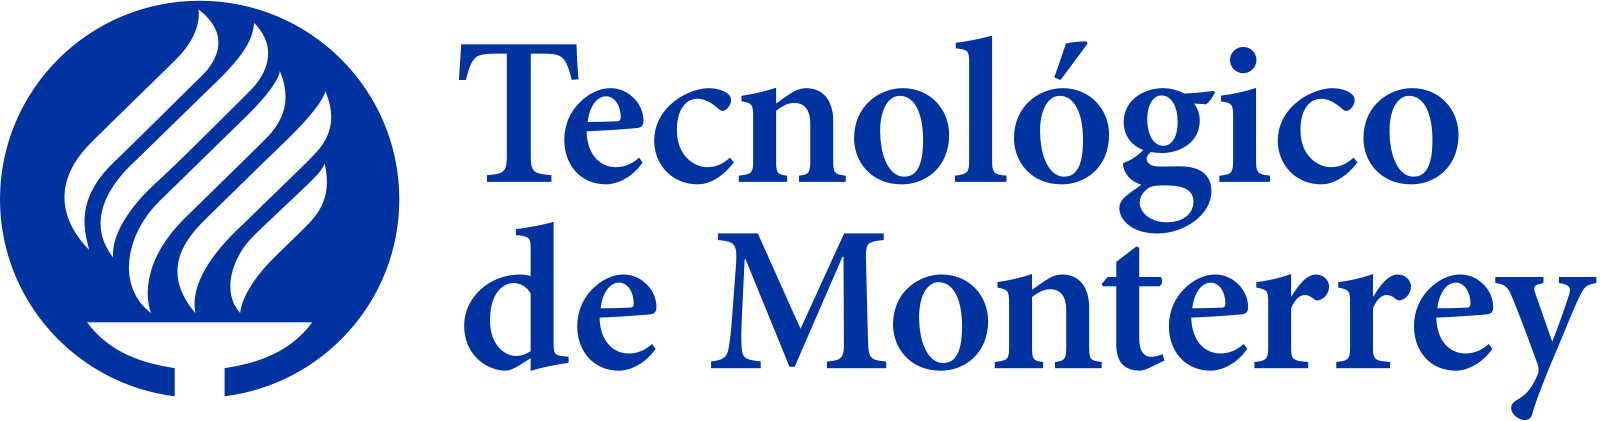

---
# Instituto Tecnológico y de Estudios Superiores de Monterrey


## **Capstone Project (Team #49)**


### **Stage 5.** Final Model


#### *Author:* Julia Gabriela Pinedo -- A01795315

#### *Professor:* Dr. Grettel Barceló Alonso
#### *Project Advisor:* Dr. Guillermo Mota Medina

---

## Table of Contents
1. [Introduction](#intro)
2. [Ensemble Methods](#algo)
   - [Homogeneous Ensemble](#homo)
   - [Heterogeneous Ensemble](#hete)
3. [Evaluation](#eval)
   - [Final Model](#final)
4. [Performance Analysis](#ana)
5. [References](#references)

---

# Introduction <a class="anchor" id="intro" ></a>

**Stage 1** introduced the required infrastructure to simulate the environment for the box-pushing loop (**Figure 1**), which is generating telemetry data for the online learning agent, as stated in **Stage 2**. Since the nature of the problem is aligned with the **Markov Decision Processes (MDP)**, a value-based learning framework is used to create experience as the agent acts through transitions: $(s_{t},a_{t},r_{t},s_{t+1})$.

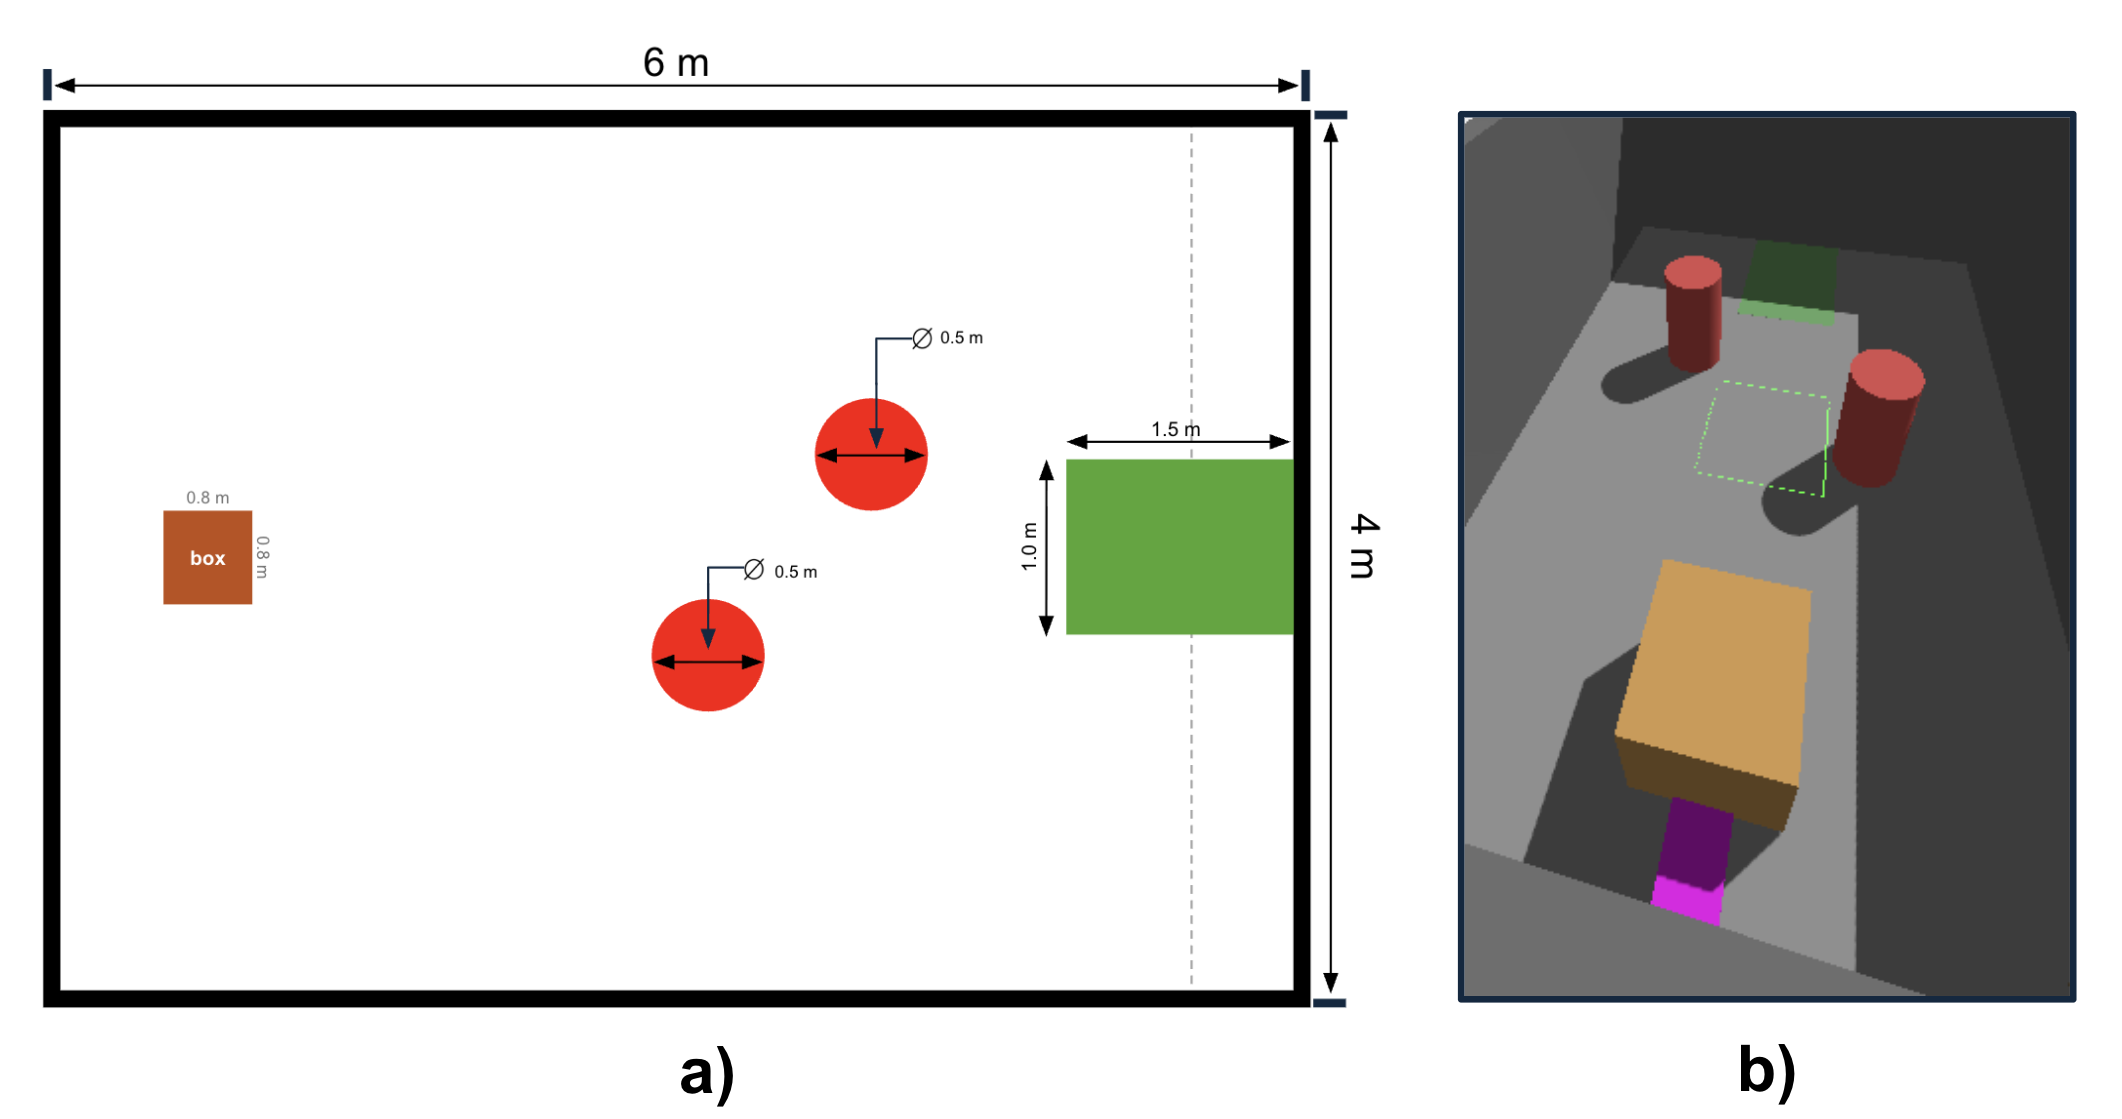
**Figure 1.** Simulation environment. a) Diagram of the arena, b) Arena modeled and simulated in Gazebo.

In **Stage 3**, the **Tabular Q-Learning** was chosen as the baseline for convergence, traceability, problem compatibility, and operational simplicity. However, after comparing its performance with six different models in **Stage 4**, the **Advantage Actor-Critic** model was selected (**Equation 1**):

$L_{\pi}(\theta) \;=\; 
-\; \mathbb{E}\!\left[
\log \pi_\theta(a_t \mid s_t)\; \hat{A}_t
\right]
\;-\;
\beta \, \mathbb{E}\!\left[ \mathcal{H}\!\big(\pi_\theta(\cdot \mid s_t)\big) \right]$ ,

$L_{V}(\phi) \;=\; 
\mathbb{E}\!\left[ \big( V_\phi(s_t) - \hat{V}_t \big)^2 \right]$ ... (**9**)

**Where:**

- $π_{θ}$ is the policy,
- $V_{ϕ}$ is the value network,
- $\hat{A}_t$ is the advantage estimate,
- $𝛽$ is the entropy weight to encourage exploration.

This algorithm combines the strengths of both policy-based and value-based methods in reinforcement learning. In this model, a policy (*actor*) is improved using an advantage baseline, while a value function (*critic*) is learned to reduce gradient variance. [13][14]

After a fine-tuning exercise, the **code snippet** of the algorithm is the following:

---
```python
class A2CAgent:
    """
    On-policy Advantage Actor-Critic (A2C) with several stabilizers.
    Collect rollout of T steps; then call update(rollout_dict)
    """
    def __init__(
        self,
        obs_dim: int,
        n_actions: int,
        lr: float = 3e-4,
        gamma: float = 0.99,
        lam: float = 0.95,
        ent_coef: float = 0.01,
        vf_coef: float = 0.5,
        hidden=(128,128),

        normalize_adv: bool = True,
        grad_clip: float = 0.5,
        lr_schedule: str = "cosine", 
        max_updates: int = 1000, 
        ent_schedule: str = "linear_decay",
        ent_coef_end: float = 0.001,
        value_loss: str = "huber", 
        value_clip_eps: float = 0.2 
    ):
        self.gamma, self.lam = gamma, lam
        self.ent_coef_start = ent_coef
        self.ent_coef_end = ent_coef_end
        self.ent_schedule = ent_schedule
        self.vf_coef = vf_coef
        self.normalize_adv = normalize_adv
        self.grad_clip = grad_clip
        self.value_loss = value_loss
        self.value_clip_eps = value_clip_eps 
        self.update_idx = 0        
        self.max_updates = max(1, int(max_updates))

        self.net = PiV(obs_dim, n_actions, hidden=hidden)
        self.opt = optim.Adam(self.net.parameters(), lr=lr)

        # Learning-rate schedule
        if lr_schedule == "cosine":
            self.lr_sched = optim.lr_scheduler.CosineAnnealingLR(self.opt, T_max=self.max_updates)
        elif lr_schedule == "linear":
            # Linear warm-down to 10% of initial LR
            self.lr_sched = optim.lr_scheduler.LambdaLR(
                self.opt,
                lr_lambda=lambda t: max(0.1, 1.0 - (t / self.max_updates))
            )
        else:
            self.lr_sched = None

        self.nA = n_actions

    # Entropy coefficient schedule (e.g., linear decay)
    def _current_ent_coef(self) -> float:
        if self.ent_schedule == "none":
            return self.ent_coef_start
        # linear decay from start -> end across max_updates
        frac = min(1.0, self.update_idx / self.max_updates)
        return (1.0 - frac) * self.ent_coef_start + frac * self.ent_coef_end

    def act(self, s):
        with torch.no_grad():
            logits, _ = self.net(torch.as_tensor(s, dtype=torch.float32))
            probs = torch.softmax(logits, dim=-1)
            a = Categorical(probs).sample().item()
        return a

    def _gae(self, rewards, values, dones, last_value):
        T = len(rewards)
        adv = torch.zeros(T, dtype=torch.float32)
        gae = 0.0
        for t in reversed(range(T)):
            # δ_t = r_t + γ(1-d_t) V(s_{t+1}) − V(s_t)
            next_v = last_value if t == T-1 else values[t+1]
            delta = rewards[t] + self.gamma * (1.0 - dones[t]) * next_v - values[t]
            gae   = delta + self.gamma * self.lam * (1.0 - dones[t]) * gae
            adv[t] = gae
        returns = adv + values
        return adv, returns

    def update(self, rollout: Dict[str, Any]):
        states = torch.as_tensor(np.array(rollout["states"]), dtype=torch.float32)
        actions = torch.as_tensor(rollout["actions"], dtype=torch.int64)
        rewards = torch.as_tensor(rollout["rewards"], dtype=torch.float32)
        dones   = torch.as_tensor(rollout["dones"],   dtype=torch.float32)
        next_state = torch.as_tensor(rollout["next_state"], dtype=torch.float32)

        logits, values = self.net(states) # V(s_t)
        with torch.no_grad():
            _, last_v = self.net(next_state.unsqueeze(0)) # V(s_{T})
            last_v = last_v.squeeze(0)

        adv, ret = self._gae(rewards, values.detach(), dones, last_v)

        # Advantage normalization
        if self.normalize_adv:
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        # Policy loss
        logp = torch.log_softmax(logits, dim=-1)
        logp_a = logp[torch.arange(len(actions)), actions]
        ent = -(torch.softmax(logits, -1) * logp).sum(-1).mean()

        loss_pi = -(logp_a * adv).mean()

        # Value loss with optional clipping and Huber
        v_pred = values
        with torch.no_grad():
            v_clipped = values + (ret - values).clamp(-self.value_clip_eps, self.value_clip_eps)
        if self.value_loss == "huber":
            loss_v_unclipped = torch.nn.functional.smooth_l1_loss(v_pred, ret, reduction="mean")
            loss_v_clipped   = torch.nn.functional.smooth_l1_loss(v_clipped, ret, reduction="mean")
        else:  # MSE
            loss_v_unclipped = torch.mean((ret - v_pred) ** 2)
            loss_v_clipped   = torch.mean((ret - v_clipped) ** 2)
        loss_v = torch.max(loss_v_unclipped, loss_v_clipped)  # pessimistic choice

        # Entropy scheduling
        ent_coef = self._current_ent_coef()

        loss = loss_pi + self.vf_coef * loss_v - ent_coef * ent

        self.opt.zero_grad()
        loss.backward()

        # Gradient clipping
        if self.grad_clip is not None and self.grad_clip > 0:
            nn.utils.clip_grad_norm_(self.net.parameters(), self.grad_clip)

        self.opt.step()

        # Step LR scheduler and update counter
        if self.lr_sched is not None:
            self.lr_sched.step()
        self.update_idx += 1

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        torch.save({
            "net": self.net.state_dict(),
            "update_idx": self.update_idx
        }, path)

    def load(self, path):
        data = torch.load(path, map_location="cpu")
        self.net.load_state_dict(data["net"])
        self.update_idx = data.get("update_idx", 0)
```
---

With the following parameters set:

| Param | Content |
|:-------------|:-----------|
| LR Actor | 0.0003  |
| LR Critic | 0.0003  |
| Gamma | 0.99 |
| LAM | 0.95  |
| Vf Coef | 0.6  |
| Actor | "hidden_sizes": [128, 128], "activation": "relu"  |
| Critic | "hidden_sizes": [128, 128], "activation": "relu"  |
| Optimizer | adam |
| Normalize Adv | True  |
| Grad Clip | 0.5  |
| LR Schedule | cosine |
| Max Updates | 800  |
| Ent Schedule | "linear_decay"  |
| Ent Coef | 0.01  |
| Ent Coef End | 0.001  |
| Value Loss | "huber"  |
| Value Clip Eps | 0.2 |
| Episodes | 100  |
| Max Steps | 100  |

This decision was not based solely on raw success rate or return magnitude, but also on:
- interpretability,
- training stability,
- control over the learning dynamics.

A2C exhibits a smoother convergence profile, a balanced trade-off between exploration and exploitation, and a more predictable critic behavior. These features make its policy updates easier to analyze and explain in terms of environmental feedback.

# Ensemble Methods <a class="anchor" id="algo" ></a>

**Ensemble learning** is a technique that aggregates two or more learners in order to produce better predictions. In other words, an ensemble model combines several individual models to produce more accurate predictions than a single model alone [20]. The techniques include:

- **Homogeneous Ensemble**: Members having a single-type base learning algorithm. Popular methods include bagging and boosting, generating diversity by sampling from or assigning weights to training examples.

- **Heterogeneous Ensemble**: Combines predictions from different types of base models to achieve a more accurate and robust final prediction.

Since we don’t have a fixed dataset in Reinforcement Learning, we have to rely on the following principle of RL: the policy generates the data, and the state-action distribution keeps shifting as the agent learns.

To adapt ensemble learning into RL, we have to decide:
- what we ensemble (policy vs. value),
- when we ensemble (during action selection vs. during training),
- how to keep learning stable under on-policy/non-stationary data.

In practice, RL ensembles are used to reduce variance and overfitting, improve robustness across spawn geometries, and expose uncertainty so we can act conservatively when needed.

We will take into account the **Advantage Actor-Critic** model, which was previously selected as the **baseline**, and also the best models (in order according to their success rate):

1. Proximal Policy Optimization
2. Deep Q-Network
3. Distributional Deep Q-Network
4. Soft Actor-Critic
5. Monte Carlo Policy Gradient

**Note:** For all the A2C-based ensembles, we reuse the exact A2C configuration from the **Introduction**. This isolates the effect of the ensembling strategy itself from any confounding due to re-tuning the base learner.

## Homogeneous Ensemble <a class="anchor" id="homo" ></a>

### A2C Bagging (multi-seed policy blending)

This method trains $K$ independent A2C policies with different random seeds (and optionally slight domain/HP variations). At decision time, this blends their action distributions. This does not mix datasets, but combines policies at **action time**. The training will remain on-policy per agent.

**Ensemble policy:**

$
\text{With policies } \{\pi_k(a\mid s)\}_{k=1}^K \text{ and nonnegative weights } w_k \text{ with } \sum_{k=1}^K w_k = 1,\quad
\pi_{\text{ens}}(a\mid s) \;=\; \sum_{k=1}^K w_k\,\pi_k(a\mid s).
$

**Code snippet**:

---
```python
@torch.no_grad()
def act_a2c_bagging(state, a2c_actors, weights=None):
    probs = []
    s = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
    for agent in a2c_actors:
        logits, _ = agent.net(s)
        probs.append(torch.softmax(logits, dim=-1).squeeze(0))
    P = torch.stack(probs, 0) # K x A

    if weights is None:
        P_ens = P.mean(0)
    else:
        w = torch.as_tensor(weights, dtype=torch.float32)
        w = w / (w.sum() + 1e-8)
        P_ens = (w[:, None] * P).sum(0)

    a = torch.distributions.Categorical(P_ens).sample().item()
    return a, P_ens
```
---

**Ensemble adaptations:**

| Context | Argument |
|:-------------|:-----------|
| What is ensembled? | Policies (same algorithm, different seeds/domain randomization)  |
| When is it applied? | Action selection (inference) at decision time  |

### A2C MC-Dropout (test-time stochastic ensembling)

This method adds dropout to the actor. At evaluation, this performs $N$ stochastic forward passes, then it averages the action distributions with an approximate Bayesian model averaging. This leverages test-time stochasticity to reduce variance and expose uncertainty.

**Ensemble policy:**

$
\text{Dropout masks } \{\omega_i\}_{i=1}^{N}, \qquad
\pi_{\text{ens}}(a \mid s) = \frac{1}{N}\sum_{i=1}^{N} \pi\!\left(a \mid s;\, \omega_i\right), \qquad
\text{(optional uncertainty)}\ \ \mathbb{V}\!\left[\pi(\cdot \mid s)\right].
$

**Code snippet**:

---
```python
# PiV network from the model, where the "DROPOUT" is included in the actor trunk
class PiV(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=(128,128), p_drop=0.1):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, hidden[0])
        self.fc2 = nn.Linear(hidden[0], hidden[1])
        self.drop = nn.Dropout(p_drop)
        self.pi = nn.Linear(hidden[1], n_actions)
        self.v  = nn.Linear(hidden[1], 1)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        h = self.drop(h)
        h = F.relu(self.fc2(h))
        logits = self.pi(h)
        val = self.v(h).squeeze(-1)
        return logits, val

@torch.no_grad()
def act_a2c_mc_dropout(agent, state, mc=8):
    agent.net.train() # enables dropout masks at inference
    s = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
    Ps = []
    for _ in range(mc):
        logits, _ = agent.net(s)
        Ps.append(torch.softmax(logits, dim=-1))
    P = torch.stack(Ps, 0).mean(0).squeeze(0)
    a = torch.distributions.Categorical(P).sample().item()
    agent.net.eval()
    return a, P
```
---

**List of parameters:**

| Param | Content |
|:-------------|:-----------|
| Gamma | 0.99 |
| GAE Lambda | 0.95  |
| Policy | "hidden_sizes": [128, 128], "activation": "relu"  |
| Optimizer | adam |
| LR Policy | 3e-4  |
| Clip Ratio | 0.2  |
| Entropy Coef | 0.01  |
| Value Coef | 0.5  |
| Rollout Len | 512 |
| Epochs per Rollout | 10  |
| Minibatch Size | 128  |
| Max Grad Norm | 0.5  |

**Ensemble adaptations:**

| Context | Argument |
|:-------------|:-----------|
| What is ensembled? | One policy sampled via different dropout masks (posterior samples)  |
| When is it applied? | Action selection (inference) average over $N$ stochastic forward passes  |

## Heterogeneous Ensemble <a class="anchor" id="hete" ></a>

### A2C + PPO (stacking with a learned gate)

This method uses a gating network $g_\phi(s)\in\Delta^2$ (softmax over experts) to route/blend between two frozen experts: A2C and PPO. Action distribution will be a convex mixture.

**Mixture-of-Experts:**

$\pi_{\text{ens}}(a \mid s)
= g_1(s)\,\pi_{\text{A2C}}(a \mid s)
+ g_2(s)\,\pi_{\text{PPO}}(a \mid s),
\qquad
g_1(s)+g_2(s)=1,\quad g_i(s)\ge 0$

This means that the model will use logged rollouts from both experts:
- for each state, the expert with the higher realized advantage/return will be labeled,
- $g_\phi$ is then trained with cross-entropy,
- the experts stay frozen, but the on-policy assumptions per expert remain true.

This is adjusted for Reinforcement Learning as we are training a router on logged outcomes.

**Code snippet**:

---
```python
class GateNet(nn.Module):
    def __init__(self, obs_dim, hidden=(64,64)):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(obs_dim, hidden[0]), nn.ReLU(),
            nn.Linear(hidden[0], hidden[1]), nn.ReLU(),
            nn.Linear(hidden[1], 2) # logits for [A2C, PPO]
        )
    def forward(self, x):
        return self.mlp(x) # raw logits

@torch.no_grad()
def act_stack_gate(state, a2c_agent, ppo_agent, gate_net):
    s = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
    # Experts
    la_a2c, _ = a2c_agent.net(s)
    la_ppo, _ = ppo_agent.net(s)
    P_a2c = torch.softmax(la_a2c, dim=-1).squeeze(0)
    P_ppo = torch.softmax(la_ppo, dim=-1).squeeze(0)
    # Gate
    g_logits = gate_net(s).squeeze(0)
    g = torch.softmax(g_logits, dim=-1) # [w_a2c, w_ppo]
    P = g[0]*P_a2c + g[1]*P_ppo
    a = torch.distributions.Categorical(P).sample().item()
    return a, P, g
```
---

**Ensemble adaptations:**

| Context | Argument |
|:-------------|:-----------|
| What is ensembled? | Policy outputs from two different actors (A2C, PPO) mixed by a gate $g(s)$  |
| When is it applied? | Action selection (interference) after training a small gate on logged rollouts  |

### A2C + DQN Critic (value-weighted blending)

This method keeps the A2C actor as the base policy but re-weights its logits using a separate DQN’s action values $Q_{\text{DQN}}(s,a)$. This means that it keeps A2C’s exploration/coverage but biases toward actions that DQN predicts as high-value. Both agents are trained in their own loops, but at action time, they combine signals without requiring off-policy re-training.

**Multiplicative re-weighting:**

$\pi_{\text{ens}}(a\mid s)\;\propto\;\pi_{\text{A2C}}(a\mid s)\,\exp\!\big(\beta\,[Q_{\text{DQN}}(s,a)-b(s)]\big)$

where $b(s)$ is a baseline to maintain a stable scale.

**Code snippet**:

---
```python
@torch.no_grad()
def act_a2c_plus_dqn(state, a2c_agent, dqn_agent, beta=0.5):
    s = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
    # A2C policy logits
    logits_a2c, _ = a2c_agent.net(s)
    logits_a2c = logits_a2c.squeeze(0) # A

    # DQN Q-values
    Q = dqn_agent.q_values(s).squeeze(0) # A, implement q_values in your DQN
    Qc = Q - Q.mean() # center as baseline b(s)=mean

    # Fuse and sample
    fused_logits = logits_a2c + beta * Qc
    P = torch.softmax(fused_logits, dim=-1)
    a = torch.distributions.Categorical(P).sample().item()
    return a, P, Q
```
---

**List of parameters:**

| Param | Content |
|:-------------|:-----------|
| Gamma | 0.99 |
| Q Net | "hidden_sizes": [128, 128], "activation": "relu"  |
| Optimizer | adam  |
| LR Q | 1e-3  |
| Double DQN | True  |
| Replay Buffer | 50000  |
| Batch Size | 64  |
| Target Update | "type": "hard", "every_steps": 1000  |
| Epsilon Schedule | "start": 1.0, "end": 0.05, "decay_steps": 5000  |
| Grad Clip | 0.5  |

**Ensemble adaptations:**

| Context | Argument |
|:-------------|:-----------|
| What is ensembled? | A2C policy logits fused with DQN values (policy-value fusion)  |
| When is it applied? | Action selection (inference) reweight A2C logits using $Q$  |

# Evaluation <a class="anchor" id="eval" ></a>

## Global Libraries

Since ROS2 and Gazebo are not designed to run natively in Jupyter (*the jupyter-ros2 library is not compatible with our current computational setup*), the RL agent logs all training artifacts online to files:

- episode metrics (`{model_name}_metrics.jsonl`).

The notebook will ingest these artifacts for evaluation and visualization without requiring the simulator to run inside Jupyter.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import precision_recall_curve, roc_curve, auc

In [2]:
# Paths for each model

# Advantage Actor-Critic (original, individual)
A2C_METRICS = Path("/Users/juliapinedo/Desktop/data/a2c_metrics_tuned.jsonl")

# A2C Bagging
A2C_BAGGING_METRICS = Path("/Users/juliapinedo/Desktop/data/a2c_bagging_metrics.jsonl")

# A2C Dropout
A2C_DROPOUT_METRICS = Path("/Users/juliapinedo/Desktop/data/a2c_dropout_metrics.jsonl")

# A2C + PPO
A2C_PPO_METRICS = Path("/Users/juliapinedo/Desktop/data/a2c_ppo_metrics.jsonl")

# A2C + DQN
A2C_DQN_METRICS = Path("/Users/juliapinedo/Desktop/data/a2c_dqn_metrics.jsonl")

In [3]:
# Custom function to retrieve the jsonl
def load_metrics_json_any(p: Path) -> pd.DataFrame:
    if not p.exists():
        raise FileNotFoundError(f"No existe: {p}")
    if p.stat().st_size == 0:
        return pd.DataFrame()
    try:
        with p.open("r", encoding="utf-8") as fh:
            return pd.read_json(fh, lines=True)
    except ValueError:
        pass
    try:
        with p.open("r", encoding="utf-8") as fh:
            first = fh.read(1)
            fh.seek(0)
            if first in "[{":
                return pd.read_json(fh)
    except ValueError:
        pass
    rows = []
    with p.open("r", encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

In [4]:
# Transform the jsonl files to DataFrame

a2c_metrics = load_metrics_json_any(A2C_METRICS)
a2c_bagging_metrics = load_metrics_json_any(A2C_BAGGING_METRICS)
a2c_dropout_metrics = load_metrics_json_any(A2C_DROPOUT_METRICS)
a2c_ppo_metrics = load_metrics_json_any(A2C_PPO_METRICS)
a2c_dqn_metrics = load_metrics_json_any(A2C_DQN_METRICS)

## Core evaluation metrics

In Reinforcement Learning, the canonical objective is the **expected return**: the sum of rewards within an episode [14]. For this task, the reward is dominated by forward progress (plus small step/rotation penalties and a terminal goal bonus), so a higher return can be close to more progress, fewer wasted steps, and reaching the goal more often. Because experience is generated online and the state distribution shifts as the policy improves, we evaluate on interleaved, frozen-policy evaluation episodes and compare them to training episodes. This is the RL analog of train/test.

1. **Episode return over time (learning curve):**

In RL, the objective is to maximize the discounted sum of rewards over an episode **(Equation 12)**:


$G_t=\sum_{k=0}^{T-t-1}\gamma^k R_{t+k+1}$ … **(12)**

Plotting episode return across training/evaluation episodes is the canonical way to see whether the policy is improving the very quantity it optimizes. For this task, the reward is explicitly shaped around forward progress (and a terminal bonus on goal), so rising evaluation returns indicate the robot is more reliably pushing the box into the goal under a frozen policy. This is important on standard RL foundations, where return is the optimization target and learning curves are the primary diagnostic for policy improvement.

2. **Success rate (goal completion):**

Return depends on reward shaping, but success does not. Tracking the fraction of episodes that end with the box fully inside the goal region gives a task completion metric that maps directly to operational success. In the multi-robot literature [6][8][9], completion rate is a staple outcome metric because it is easy to interpret for stakeholders and robust to details of the stepwise reward.


3. **Episode length/steps to success (efficiency):**

Among successful episodes, fewer steps mean higher throughput and lower energy/time cost. Tracking the distribution of steps to success complements the success rate. A policy that finishes more often and faster is preferable to one that finishes only by taking excessively long detours.

**Floor criteria:**

| Metric |
|:-------------|
| Eval success rate ≥ 0.20 |
| Median steps-to-success ≤ 80 |
| Positive learning trend on eval (rolling/local slope > 0) |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 |

**Note**: The principal metric is `eval_success_rate` because it directly reflects task completion under the evaluation protocols and is robust to reward-shaping choices. The models will be presented in order by the highest success rate.

In [5]:
# ***************************** HELPER METHODS ******************************
def rolling_mean(series, w=7):
    return series.rolling(w, min_periods=1).mean()

def align_train_on_eval(train_eps, train_vals, eval_eps):
    if len(train_eps) == 0 or len(eval_eps) == 0:
        return np.full(len(eval_eps), np.nan, dtype=float)
    order = np.argsort(train_eps)
    te = np.asarray(train_eps, dtype=float)[order]
    tv = np.asarray(train_vals, dtype=float)[order]
    ee = np.asarray(eval_eps, dtype=float)
    ee_clip = np.clip(ee, te.min(), te.max())
    return np.interp(ee_clip, te, tv)

def moving_slope(y, w=9):
    y = np.asarray(y, dtype=float)
    x = np.arange(len(y), dtype=float)
    s = np.full(len(y), np.nan)
    for i in range(len(y)):
        j0 = max(0, i - w + 1)
        xi, yi = x[j0:i+1], y[j0:i+1]
        mask = np.isfinite(yi)
        if mask.sum() >= 3:
            s[i] = np.polyfit(xi[mask], yi[mask], 1)[0]
    return s

# *************************** MINIMUM THRESHOLDS ****************************
MIN_SUCCESS = 0.20
MAX_MEDIAN_STEPS = 80
MIN_SLOPE_LAST = 0.0
MIN_GAP = -1.0  # eval − train

# ***************************** METRIC ANALYZER *****************************
def analyze_model(metrics_df, model_name="MODEL", w=7, slope_tail_eval_points=20):
    req = ["episode","return","steps","success","eval_mode"]
    for c in req:
        if c not in metrics_df.columns:
            raise ValueError(f"[{model_name}] missing required column: {c}")

    # 1) Prep & rolling
    M = metrics_df.sort_values("episode").reset_index(drop=True).copy()
    M["success"] = M["success"].astype(float)
    M["return_smooth"]  = rolling_mean(M["return"].astype(float),  w=w)
    M["success_smooth"] = rolling_mean(M["success"].astype(float), w=w)

    is_eval  = (M["eval_mode"] == 1)
    is_train = ~is_eval

    # 2) Streams for gap/slope (returns)
    train_returns = M.loc[is_train, "return"].reset_index(drop=True)
    eval_returns  = M.loc[is_eval,  "return"].reset_index(drop=True)
    train_smooth  = rolling_mean(train_returns, w=w).values
    eval_smooth   = rolling_mean(eval_returns,  w=w).values
    train_eps = M.loc[is_train, "episode"].values
    eval_eps  = M.loc[is_eval,  "episode"].values
    train_on_eval = align_train_on_eval(train_eps, train_smooth, eval_eps)
    gap = eval_smooth - train_on_eval
    mean_gap = float(np.nanmean(gap)) if len(gap) else np.nan

    # Tail slope on eval returns
    if len(eval_smooth) >= 3:
        tlen  = min(slope_tail_eval_points, len(eval_smooth))
        tail  = eval_smooth[-tlen:]
        x_tail = np.arange(len(tail), dtype=float)
        eval_tail_slope = float(np.polyfit(x_tail, tail, 1)[0])
    else:
        eval_tail_slope = np.nan

    # Success curves per stream
    succ_train = rolling_mean(M.loc[is_train, "success"].reset_index(drop=True), w=w).values
    succ_eval  = rolling_mean(M.loc[is_eval,  "success"].reset_index(drop=True), w=w).values
    succ_train_eps = M.loc[is_train, "episode"].values
    succ_eval_eps  = M.loc[is_eval,  "episode"].values

    # Success stats
    eval_success_rate  = float(M.loc[is_eval, "success"].mean()) if is_eval.any() else np.nan
    eval_success_steps = M.loc[is_eval & (M["success"]==1), "steps"].values
    eval_median_steps  = float(np.median(eval_success_steps)) if len(eval_success_steps) else np.nan

    mean_return_train = float(M.loc[is_train, "return"].mean()) if is_train.any() else np.nan
    mean_return_eval  = float(M.loc[is_eval,  "return"].mean())  if is_eval.any()  else np.nan

    # 3) One-row figure
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)

    # (A) Episode return over time
    ax = axes[0]
    ax.plot(M.loc[is_train, "episode"], M.loc[is_train, "return"], ".", alpha=0.30, label="train (raw)")
    ax.plot(M.loc[is_eval,  "episode"], M.loc[is_eval,  "return"],  "x", alpha=0.60, label="eval (raw)")
    ax.plot(M["episode"], M["return_smooth"], "-", label=f"all (rolling {w})")
    ax.set_title(f"[{model_name}] Return over time"); ax.set_xlabel("Episode"); ax.set_ylabel("Return")
    ax.legend(loc="best", fontsize=8)

    # (B) Success rate over time
    ax = axes[1]

    # Raw points
    ax.scatter(M.loc[is_train, "episode"], M.loc[is_train, "success"],
               s=10, alpha=0.25, label="train success (raw)", color="tab:blue")
    ax.scatter(M.loc[is_eval,  "episode"], M.loc[is_eval,  "success"],
               s=22, alpha=0.55, marker="x", label="eval success (raw)", color="tab:orange")

    # Rolling means per stream (use a smaller w for sparse evals)
    w_eval = min(w, 5)
    succ_train_roll = rolling_mean(M.loc[is_train, "success"].reset_index(drop=True), w=w)
    succ_eval_roll  = rolling_mean(M.loc[is_eval,  "success"].reset_index(drop=True),  w=w_eval)

    train_eps = M.loc[is_train, "episode"].to_numpy()
    eval_eps  = M.loc[is_eval,  "episode"].to_numpy()

    # Lines drawn only where data exist
    if len(train_eps) >= 2:
        ax.plot(train_eps, succ_train_roll, "-", lw=2.0, color="tab:blue",
                label=f"train success (rolling {w})")

    if len(eval_eps) >= 2:
        ax.plot(eval_eps, succ_eval_roll, "-o", lw=2.2, ms=3.0, color="tab:orange",
                label=f"eval success (rolling {w_eval})", zorder=3)

    for e in eval_eps:
        ax.axvline(e, color="k", alpha=0.05, linewidth=1)

    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"[{model_name}] Success rate (train vs eval)")
    ax.set_xlabel("Episode"); ax.set_ylabel("Success (0/1)")
    ax.legend(loc="best", fontsize=8)

    # (C) Episode steps
    ax = axes[2]
    ax.plot(M["episode"], M["steps"], ".", alpha=0.5)
    ax.set_title(f"[{model_name}] Episode steps"); ax.set_xlabel("Episode"); ax.set_ylabel("Steps")

    # (D) Generalization gap at eval points
    ax = axes[3]
    if len(eval_eps) == len(gap) and len(gap) > 0:
        ax.plot(eval_eps, gap, "-o", label="Eval − Train")
        ax.axhline(0, ls="--", color="gray")
        ax.legend(loc="best", fontsize=8)
    else:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(f"[{model_name}] Gap (eval points)"); ax.set_xlabel("Episode"); ax.set_ylabel("Return gap")

    plt.show()

    # 4) Summary DataFrame
    summary = pd.DataFrame([{
        "model": model_name,
        "eval_success_rate": eval_success_rate,
        "eval_median_steps_success": eval_median_steps,
        "eval_tail_return_slope": eval_tail_slope,
        "mean_eval_minus_train_gap": mean_gap,
        "mean_return_train": mean_return_train,
        "mean_return_eval": mean_return_eval,
    }])
    return summary

In [6]:
# ****************** LOOP TO ANALYZE ALL MODELS AT ONCE *********************

def analyze_all_models_from_dfs(dfs: dict, w=7, slope_tail_eval_points=20):
    all_rows = []
    for name, df in dfs.items():
        try:
            print(f"{name.upper()}")
            summary = analyze_model(
                metrics_df=df,
                model_name=name.upper(),
                w=w,
                slope_tail_eval_points=slope_tail_eval_points
            )
            display(summary)  # Per-model numeric table
            all_rows.append(summary)
            print("\n")
        except Exception as e:
            print(f"[{name}] error: {e}")

    if not all_rows:
        return pd.DataFrame()

    out = pd.concat(all_rows, ignore_index=True)

    # Order by eval_success_rate (desc), keep others stable as tiebreakers if present
    order_cols = [c for c in ["eval_success_rate",
                              "PASS_success_rate",
                              "eval_median_steps_success"] if c in out.columns]
    if "eval_success_rate" in out.columns:
        out = out.sort_values(by="eval_success_rate", ascending=False, kind="mergesort").reset_index(drop=True)

    return out

A2C


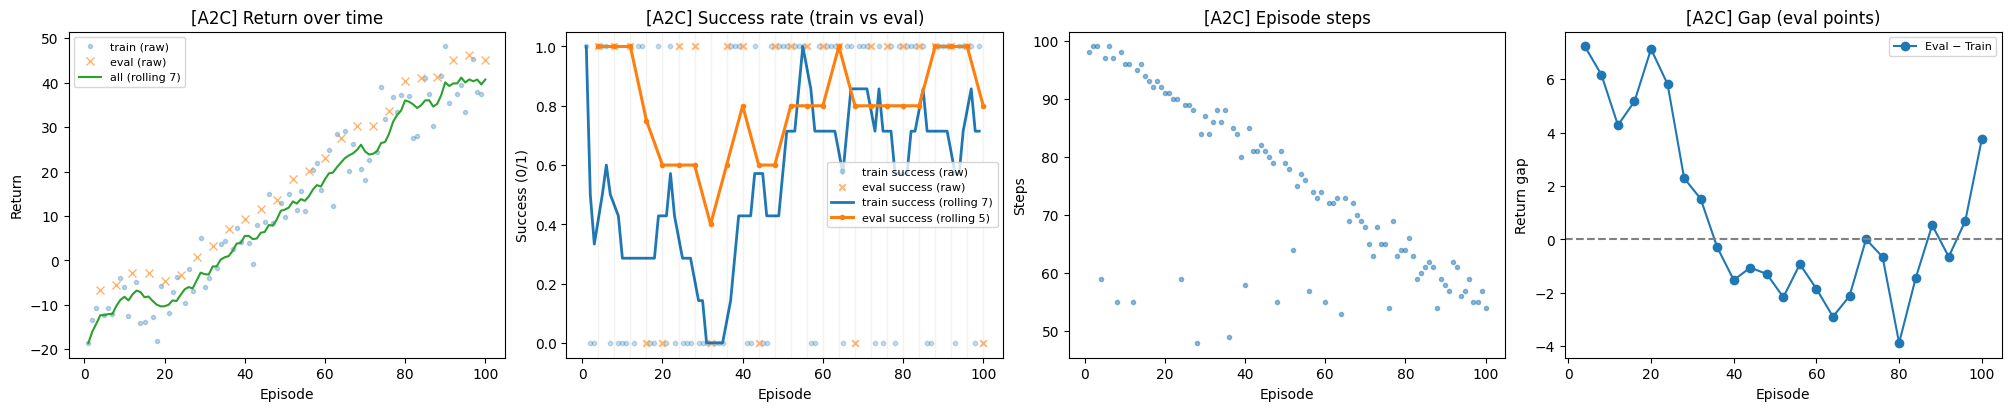

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,A2C,0.76,57.0,2.614411,0.950283,12.590413,18.48256




A2C_BAGGING


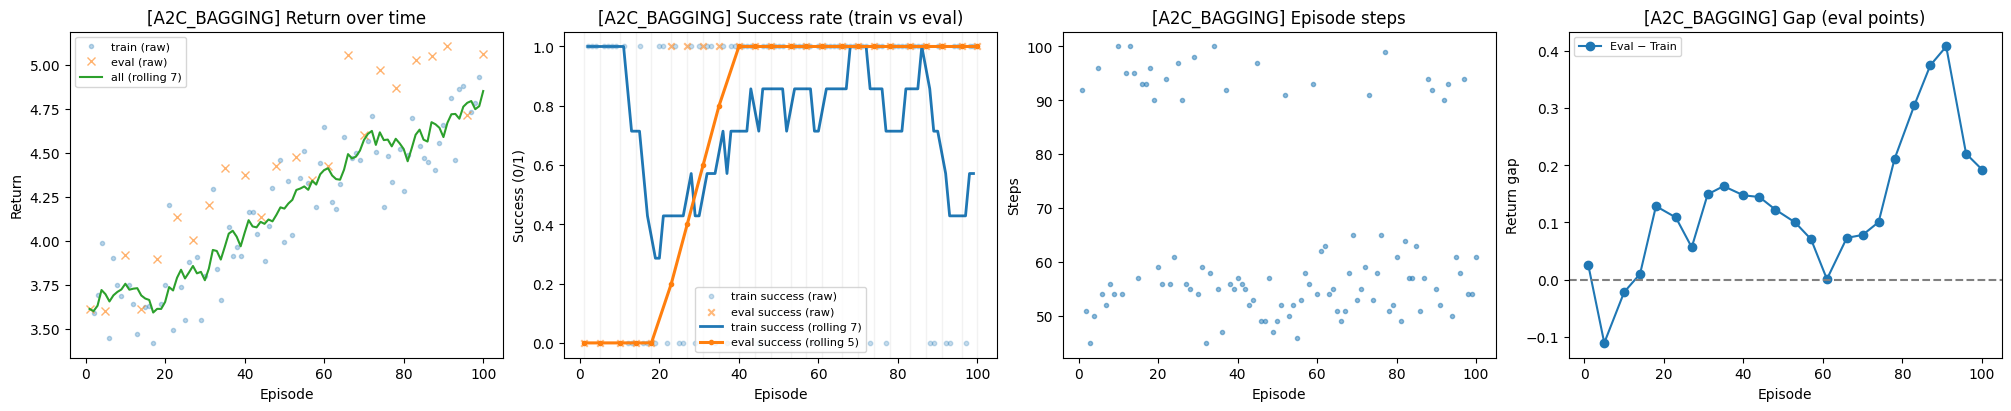

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,A2C_BAGGING,0.791667,56.0,0.067781,0.127486,4.168888,4.419617




A2C_DROPOUT


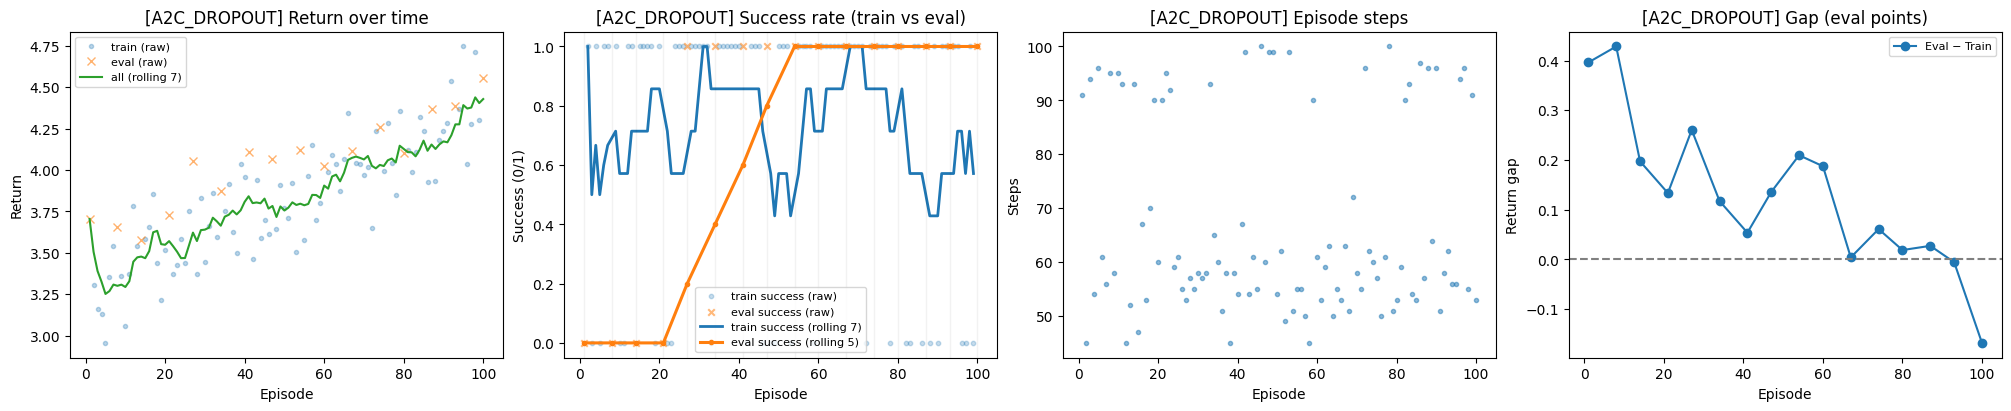

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,A2C_DROPOUT,0.75,60.0,0.042692,0.128605,3.822711,4.042331




A2C_PPO


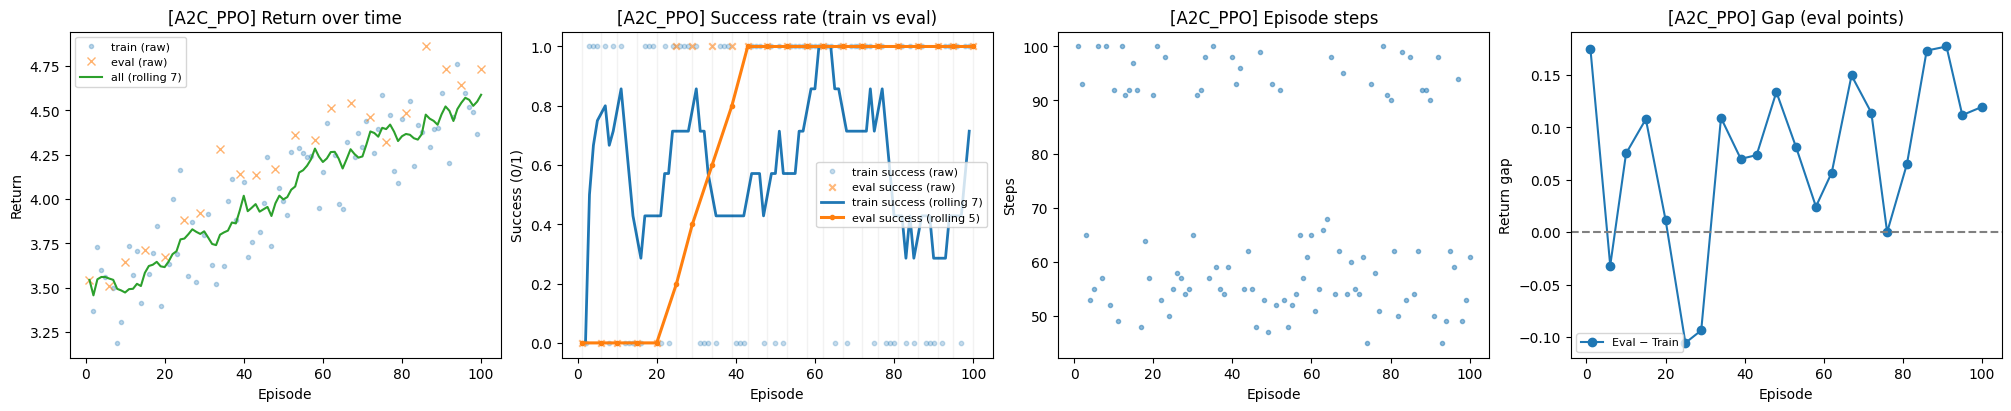

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,A2C_PPO,0.772727,55.0,0.060645,0.072565,4.026563,4.209441




A2C_DQN


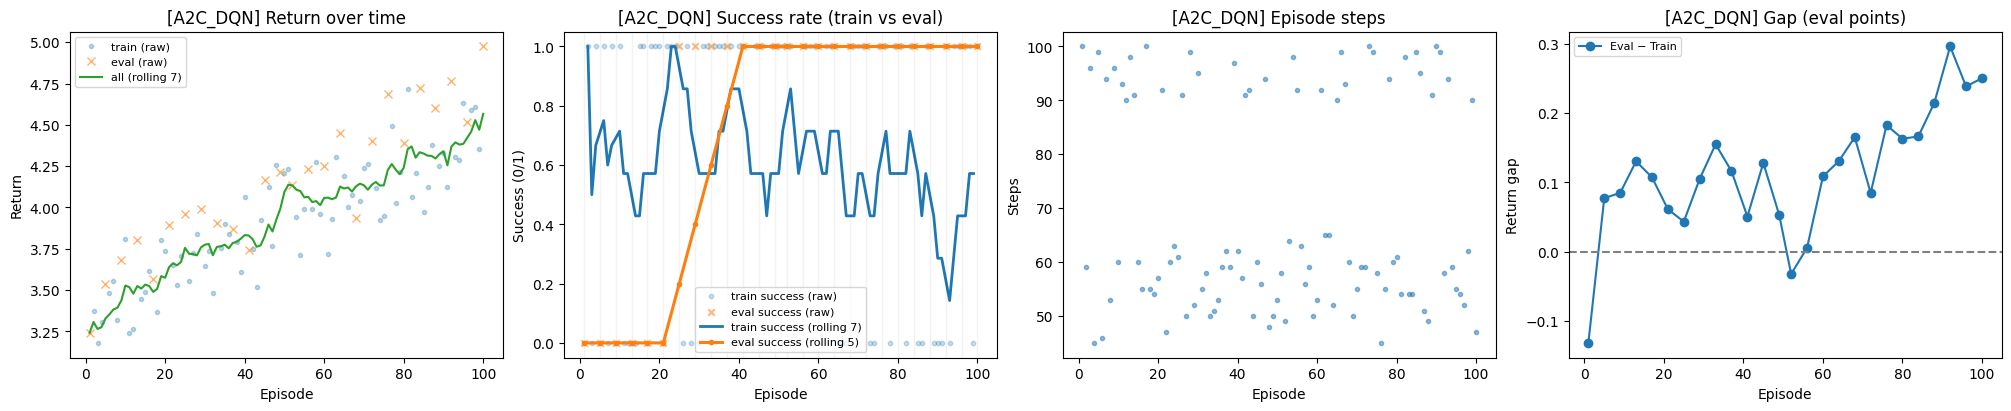

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,A2C_DQN,0.769231,54.0,0.048345,0.113733,3.917793,4.139985


In [7]:
dfs = {
    "a2c": a2c_metrics,
    "a2c_bagging": a2c_bagging_metrics,
    "a2c_dropout": a2c_dropout_metrics,
    "a2c_ppo": a2c_ppo_metrics,
    "a2c_dqn": a2c_dqn_metrics,
}

summary_all = analyze_all_models_from_dfs(dfs, w=7, slope_tail_eval_points=20)

Let's observe the runtime across each model:

In [8]:
def _fmt_hms(secs: float) -> str:
    secs = float(secs if np.isfinite(secs) else 0.0)
    h = int(secs // 3600)
    m = int((secs % 3600) // 60)
    s = int(round(secs % 60))
    return f"{h:02d}:{m:02d}:{s:02d}"

def _summarize_runtime_one(df: pd.DataFrame, model_name: str) -> dict:
    if "episode_duration_sec" not in df.columns:
        raise ValueError(f"[{model_name}] missing column: episode_duration_sec")

    dur = pd.to_numeric(df["episode_duration_sec"], errors="coerce").fillna(0.0)
    is_eval = (df["eval_mode"] == 1) if "eval_mode" in df.columns else pd.Series(False, index=df.index)

    total_sec = float(dur.sum())
    train_sec = float(dur.loc[~is_eval].sum())
    eval_sec  = float(dur.loc[ is_eval].sum())

    n_eps = int(len(df))
    mean_sec = float(total_sec / n_eps) if n_eps else np.nan

    return {
        "model": model_name,
        "episodes": n_eps,
        "total_sec": total_sec,
        "train_sec": train_sec,
        "eval_sec": eval_sec,
        "mean_sec_per_episode": mean_sec,
        "total_hms": _fmt_hms(total_sec),
        "train_hms": _fmt_hms(train_sec),
        "eval_hms":  _fmt_hms(eval_sec),
    }

In [9]:
def summarize_runtime_by_model(dfs: dict) -> pd.DataFrame:
    rows = []
    for name, df in dfs.items():
        rows.append(_summarize_runtime_one(df, model_name=name.upper()))
    out = pd.DataFrame(rows)
    out = out.sort_values("total_sec", ascending=True).reset_index(drop=True)
    return out

runtime_table = summarize_runtime_by_model(dfs)
runtime_table

,model,episodes,total_sec,train_sec,eval_sec,mean_sec_per_episode,total_hms,train_hms,eval_hms
0,A2C,100,370.747,292.728,78.019,3.70747,00:06:11,00:04:53,00:01:18
1,A2C_DROPOUT,100,494.998,430.160,64.838,4.94998,00:08:15,00:07:10,00:01:05
2,A2C_DQN,100,500.000,377.894,122.106,5.00000,00:08:20,00:06:18,00:02:02
3,A2C_PPO,100,504.995,404.611,100.384,5.04995,00:08:25,00:06:45,00:01:40
4,A2C_BAGGING,100,519.998,407.281,112.717,5.19998,00:08:40,00:06:47,00:01:53


In [10]:
display(summary_all)

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,A2C_BAGGING,0.791667,56.0,0.067781,0.127486,4.168888,4.419617
1,A2C_PPO,0.772727,55.0,0.060645,0.072565,4.026563,4.209441
2,A2C_DQN,0.769231,54.0,0.048345,0.113733,3.917793,4.139985
3,A2C,0.760000,57.0,2.614411,0.950283,12.590413,18.482560
4,A2C_DROPOUT,0.750000,60.0,0.042692,0.128605,3.822711,4.042331


In summary:

### 1. A2C Bagging (multi-seed policy blending)

Has a total runtime of **8 minutes, 40 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.79 | Yes  |
| Median steps-to-success ≤ 80 | ~56 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 0.067 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.127  | Yes  |

### 2. A2C + PPO (stacking with a learned gate)

Has a total runtime of **8 minutes, 25 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.77 | Yes  |
| Median steps-to-success ≤ 80 | ~55 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 0.060 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.072  | Yes  |

### 3. A2C + DQN Critic (value-weighted blending)

Has a total runtime of **8 minutes, 20 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.76 | Yes  |
| Median steps-to-success ≤ 80 | ~54 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 0.048 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.113  | Yes  |

### 4. Advantage Actor-Critic

Has a total runtime of **6 minutes, 11 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.76 | Yes  |
| Median steps-to-success ≤ 80 | ~57 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 2.614 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.9502  | Yes  |

### 5. A2C MC-Dropout (test-time stochastic ensembling)

Has a total runtime of **8 minutes, 15 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.75 | Yes  |
| Median steps-to-success ≤ 80 | ~60 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 0.042 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.127  | Yes  |

We observe the following:

The **A2C-Bagging** is the best overall, with a success of **0.79** and a healthy mean gap with eval returns above train across the run. The return curve rises steadily, where the eval success line ramps to 1 and stays there. The gap trends positively late, so there is no sign of an overfitting signal. The total runtime (compared to the **A2C Original** of 6 minutes) is now 8 minutes and 40 seconds, as expected since $K$ actors are voting.

For the **A2C-MC-Dropout**, the eval success is **0.75**. The curves show a clear upward trend, and the eval is generally higher than the train. The curves show that the gap softens near the end (one or two points dip toward zero), hinting at mild over-regularization rather than overfit. This model is the fastest of the ensembles, with 8 minutes and 15 seconds of runtime.

For the **A2C + PPO**, the model is balanced and stable, reaching an evaluation success of **0.77**. The return climbs smoothly, and the gap oscillates around zero but trends slightly positive late, indicating a good generalization without overfitting. The runtime is about 8 minutes and 25 seconds.

Lastly, the **A2C + DQN Critic** is still competitive, but with lower step counts. The eval success is **0.76**. Eval returns stay above train, and the gap increases through time, suggesting an improving generalization. However, the run time is 8 minutes and 20 seconds.

## Final Model <a class="anchor" id="final" ></a>

Let's do a **train vs. eval** analysis:

In [11]:
def analyze_train_vs_eval(metrics: pd.DataFrame, w: int = 7, tail_eval_points: int = 20, plot: bool = True):
    """
    Compare train vs eval learning curves (returns), quantify generalization gap,
    and return a one-row summary DataFrame.

    Expected columns in `metrics`: episode, return, success, eval_mode
    """
    req = ["episode", "return", "success", "eval_mode"]
    missing = [c for c in req if c not in metrics.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # Sort and build masks
    M = metrics.sort_values("episode").reset_index(drop=True).copy()
    is_eval  = (M["eval_mode"] == 1)
    is_train = ~is_eval

    # Smooth per-stream returns
    train_returns = M.loc[is_train, "return"].reset_index(drop=True)
    eval_returns  = M.loc[is_eval,  "return"].reset_index(drop=True)
    train_curve   = rolling_mean(train_returns, w=w).reset_index(drop=True)
    eval_curve    = rolling_mean(eval_returns,  w=w).reset_index(drop=True)

    # X-axes (episodes)
    train_eps = M.loc[is_train, "episode"].values
    eval_eps  = M.loc[is_eval,  "episode"].values

    # Align train curve to eval episodes and compute gap
    train_on_eval = align_train_on_eval(train_eps, train_curve.values, eval_eps)
    gap = eval_curve.values - train_on_eval
    mean_gap = float(np.nanmean(gap)) if len(gap) else np.nan

    # Tail slope on eval curve (formal “still improving?” check)
    if len(eval_curve) >= 3:
        t = min(tail_eval_points, len(eval_curve))
        y_tail = eval_curve.values[-t:]
        x_tail = np.arange(t, dtype=float)
        eval_tail_slope = float(np.polyfit(x_tail, y_tail, 1)[0])
    else:
        eval_tail_slope = np.nan

    # Optional plot (your original style)
    if plot:
        fig, ax = plt.subplots(figsize=(8,4))
        ax.plot(eval_eps, eval_curve.values, "-o", label="Eval (smoothed)")
        ax.plot(eval_eps, train_on_eval, "-o", label="Train (nearby episodes, smoothed)")
        ax.axhline(0, color="k", lw=0.5)
        ax.set_title("Train vs Eval (returns)")
        ax.set_xlabel("Episode (eval points)")
        ax.set_ylabel("Return")
        ax.legend()
        plt.show()

    # Summary numbers (no prints; returned as a DataFrame)
    summary = pd.DataFrame([{
        "mean_return_train_all": float(M.loc[is_train, "return"].mean()) if is_train.any() else np.nan,
        "mean_return_eval_only": float(M.loc[is_eval,  "return"].mean()) if is_eval.any()  else np.nan,
        "mean_success_train_all": float(M.loc[is_train, "success"].mean()) if is_train.any() else np.nan,
        "mean_success_eval_only": float(M.loc[is_eval,  "success"].mean()) if is_eval.any()  else np.nan,
        "mean_eval_minus_train_gap": mean_gap,
        "eval_tail_return_slope": eval_tail_slope,
        "window": int(w),
        "tail_eval_points": int(tail_eval_points),
        "n_train_eps": int(is_train.sum()),
        "n_eval_eps": int(is_eval.sum()),
    }])
    return summary

### A2C Bagging (multi-seed policy blending)

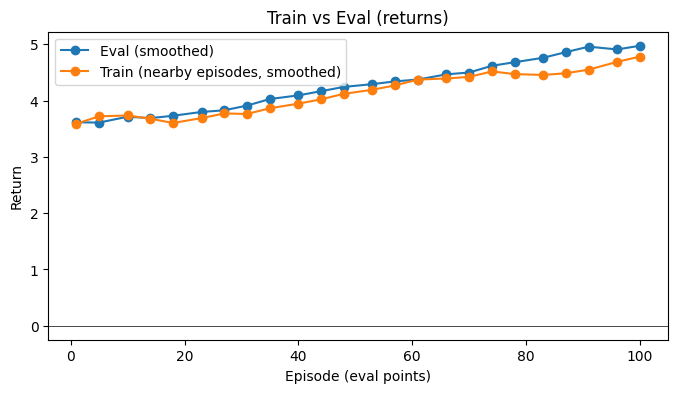

,mean_return_train_all,mean_return_eval_only,mean_success_train_all,mean_success_eval_only,mean_eval_minus_train_gap,eval_tail_return_slope,window,tail_eval_points,n_train_eps,n_eval_eps
0,4.168888,4.419617,0.723684,0.791667,0.127486,0.067781,7,20,76,24


In [12]:
summary_a2c_bagging = analyze_train_vs_eval(metrics=a2c_bagging_metrics)
display(summary_a2c_bagging)

### A2C + PPO (stacking with a learned gate)

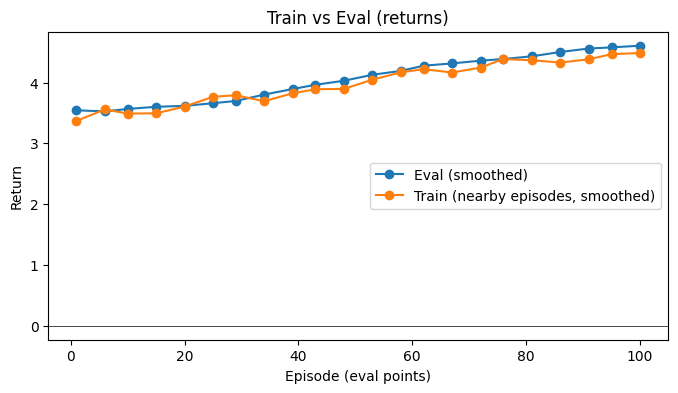

,mean_return_train_all,mean_return_eval_only,mean_success_train_all,mean_success_eval_only,mean_eval_minus_train_gap,eval_tail_return_slope,window,tail_eval_points,n_train_eps,n_eval_eps
0,4.026563,4.209441,0.602564,0.772727,0.072565,0.060645,7,20,78,22


In [13]:
summary_a2c_ppo = analyze_train_vs_eval(metrics=a2c_ppo_metrics)
display(summary_a2c_ppo)

### A2C + DQN Critic (value-weighted blending)

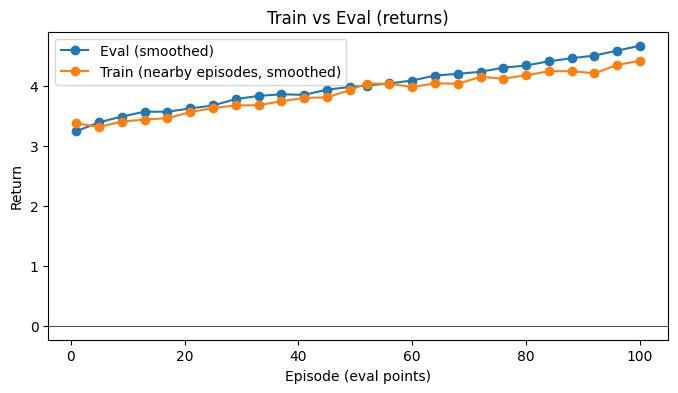

,mean_return_train_all,mean_return_eval_only,mean_success_train_all,mean_success_eval_only,mean_eval_minus_train_gap,eval_tail_return_slope,window,tail_eval_points,n_train_eps,n_eval_eps
0,3.917793,4.139985,0.608108,0.769231,0.113733,0.048345,7,20,74,26


In [14]:
summary_a2c_dqn = analyze_train_vs_eval(metrics=a2c_dqn_metrics)
display(summary_a2c_dqn)

### A2C MC-Dropout (test-time stochastic ensembling)

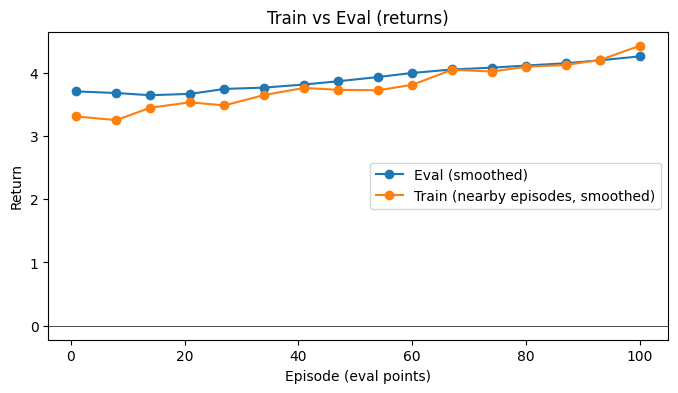

,mean_return_train_all,mean_return_eval_only,mean_success_train_all,mean_success_eval_only,mean_eval_minus_train_gap,eval_tail_return_slope,window,tail_eval_points,n_train_eps,n_eval_eps
0,3.822711,4.042331,0.714286,0.75,0.128605,0.042692,7,20,84,16


In [15]:
summary_a2c_dropout = analyze_train_vs_eval(metrics=a2c_dropout_metrics)
display(summary_a2c_dropout)

The four curves generally improve and have the eval staying above the train. However, the curve for the **A2C Bagging** is the only one consistently above train and with a smooth rise. Also, the late-stage slope is the strongest of the four, with a healthy gap on eval-train, and no drift into negative territory. Since it also posts the highest eval success while keeping reasonable steps, the best ensemble model is:

#### A2C Bagging

This is because the model:

- reduces variance across seeds,
- preserves on-policy learning,
- Its mixture policy is safe for discrete control
- It's simple and reproducible.

However, the run time is 8:40 minutes, which is slightly higher than the rest of the ensemble models. However, this computational cost is still within the 10-minute budget, so this is essentially the cleanest “*no overfit, still improving*” profile.

# Performance Analysis <a class="anchor" id="ana" ></a>

## 1. Trend and Prediction (Time Series)

This graph is useful as it visualizes whether the agent continues to improve in eval and whether there is a risk of stagnation. For RL, we will use return/success only in eval and estimate a local slope with a short-term projection.

This graph is important for RL methods as it shows if the policy is still improving on held-out behavior (eval) rather than just on noisy training rollouts. It directly maps to the floor value: `positive eval slope > 0`.

In [16]:
def rolling_mean(s, w=7):
    return s.rolling(w, min_periods=1).mean()

def plot_learning_with_forecast(df, w=7, tail_eval_points=20, forecast_steps=10, title_prefix=""):
    M = df.sort_values("episode").reset_index(drop=True)
    is_eval = (M["eval_mode"] == 1)
    ep_all  = M["episode"]

    # Return (all episodes) rolling
    ret_all_roll = rolling_mean(M["return"], w)
    # Eval-only rolling return for trend
    eval_ep   = M.loc[is_eval, "episode"]
    eval_roll = rolling_mean(M.loc[is_eval, "return"], w)

    # Tail slope on eval
    slope = np.nan
    if len(eval_roll.dropna()) >= 3:
        y = eval_roll.dropna().values
        x = np.arange(len(y), dtype=float)
        t = min(tail_eval_points, len(y))
        m, b = np.polyfit(x[-t:], y[-t:], 1) # local slope
        slope = float(m)

        # dashed short forecast
        x_f  = np.arange(len(y), len(y)+forecast_steps, dtype=float)
        y_f  = m * x_f + b
    else:
        m = b = None

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    ax[0].plot(ep_all, ret_all_roll, label=f"Return (rolling {w})")
    ax[0].scatter(eval_ep, M.loc[is_eval, "return"], s=14, alpha=0.45, label="Eval (raw)")
    ax[0].set_title(f"{title_prefix}Return over time"); ax[0].set_xlabel("Episode"); ax[0].set_ylabel("Return"); ax[0].legend()

    ax[1].plot(eval_ep, eval_roll, label=f"Eval return (rolling {w})")
    if m is not None:
        # x-axis spacing for fake forecast: extend episodes by same median gap
        d = np.median(np.diff(eval_ep)) if len(eval_ep) > 1 else 1.0
        ax[1].plot(eval_ep.iloc[-1] + d * (np.arange(1, len(x_f)+1)), y_f, "--", label=f"Forecast (slope≈{slope:.3f})")
    ax[1].set_title(f"{title_prefix}Eval trend + short forecast"); ax[1].set_xlabel("Episode"); ax[1].set_ylabel("Return"); ax[1].legend()
    plt.show()

    print(f"Local eval slope on the last {min(tail_eval_points, len(eval_roll))} eval points: {slope:.6f}")

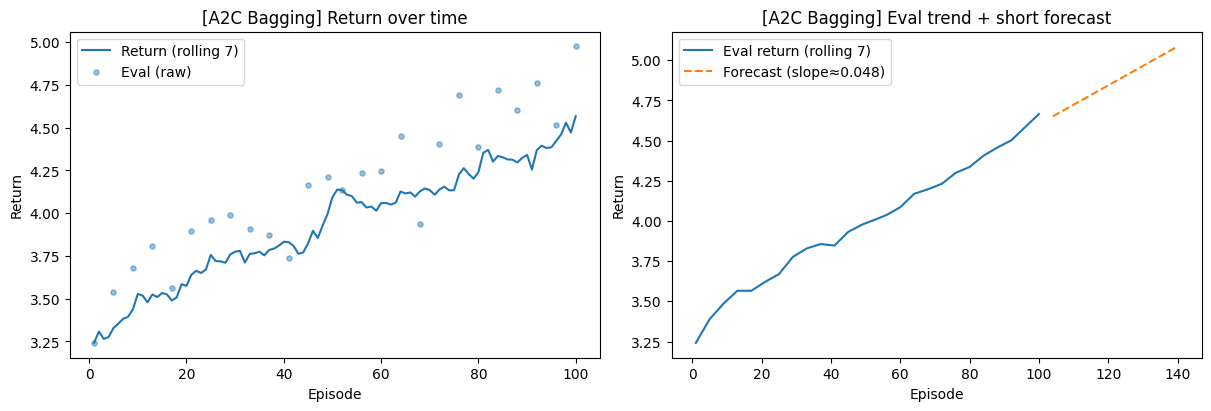

Local eval slope on the last 20 eval points: 0.048345


In [17]:
plot_learning_with_forecast(a2c_dqn_metrics, w=7, tail_eval_points=20, forecast_steps=10, title_prefix="[A2C Bagging] ")

The graph shows a steadily rising evaluation return, where raw eval points fluctuate around a smooth 7-episode rolling curve, with no late-stage collapse. The right panel computes the local slope on the last 20 eval points. The extension suggests a continued, modest improvement, where the ensemble still has learning headroom rather than saturating. Since this is a simple local linear extrapolation, it is a useful diagnostic that helped us to identify that the model has a healthy and variance-reduced learning.

## 2. ECDF of Returns (Train vs Eval)

This graph will help us to see how the entire distribution of returns shifts from train to eval. If the eval ECDF is consistently to the right, then the eval returns dominate the train (meaning a good generalization).

This is used in RL to compare the full return distributions to detect generalization gaps.

In [18]:
def plot_ecdf_returns(df, title_prefix=""):
    M = df.sort_values("episode")
    is_eval = (M["eval_mode"] == 1)

    tr = M.loc[~is_eval, "return"].dropna().to_numpy(dtype=float)
    ev = M.loc[ is_eval, "return"].dropna().to_numpy(dtype=float)

    def ecdf(x):
        x = np.sort(x)
        y = np.linspace(0, 1, len(x), endpoint=True)
        return x, y

    x_tr, y_tr = ecdf(tr) if len(tr) else (np.array([]), np.array([]))
    x_ev, y_ev = ecdf(ev) if len(ev) else (np.array([]), np.array([]))

    # Plot
    plt.figure(figsize=(6,4))
    if len(tr): plt.plot(x_tr, y_tr, label="Train ECDF")
    if len(ev): plt.plot(x_ev, y_ev, label="Eval ECDF")
    plt.xlabel("Return"); plt.ylabel("Cumulative probability")
    plt.title(f"{title_prefix}ECDF of returns (train vs eval)")
    plt.legend(); plt.grid(alpha=.2); plt.show()

    # Numerical summary
    stats = {}
    if len(tr) and len(ev):
        # Means / medians / IQRs
        def q(x, p): return float(np.quantile(x, p))
        stats.update({
            "n_train": int(len(tr)),
            "n_eval":  int(len(ev)),
            "mean_train": float(np.mean(tr)),
            "mean_eval":  float(np.mean(ev)),
            "delta_mean_eval_minus_train": float(np.mean(ev) - np.mean(tr)),
            "median_train": float(np.median(tr)),
            "median_eval":  float(np.median(ev)),
            "iqr_train": float(q(tr, 0.75) - q(tr, 0.25)),
            "iqr_eval":  float(q(ev, 0.75) - q(ev, 0.25)),
            "p10_train": float(q(tr, 0.10)), "p90_train": float(q(tr, 0.90)),
            "p10_eval":  float(q(ev, 0.10)), "p90_eval":  float(q(ev, 0.90)),
        })

        # Two-sample KS statistic
        xs = np.sort(np.unique(np.concatenate([tr, ev])))
        F_tr = np.searchsorted(np.sort(tr), xs, side="right") / len(tr)
        F_ev = np.searchsorted(np.sort(ev), xs, side="right") / len(ev)
        ks = float(np.max(np.abs(F_tr - F_ev)))
        stats["ks_statistic"] = ks

        # P( eval_return > train_return )
        tr_sorted = np.sort(tr)
        greater_counts = np.searchsorted(tr_sorted, ev, side="right")  # for each ev_i
        p_ev_gt_tr = float(np.sum(greater_counts) / (len(tr) * len(ev)))
        stats["P(eval > train)"] = p_ev_gt_tr

        # Average absolute ECDF gap on a uniform grid (0..1 scale)
        grid = np.linspace(min(xs), max(xs), 500)
        Ftr_g = np.searchsorted(np.sort(tr), grid, side="right") / len(tr)
        Fev_g = np.searchsorted(np.sort(ev), grid, side="right") / len(ev)
        stats["mean_abs_ecdf_gap"] = float(np.mean(np.abs(Ftr_g - Fev_g)))

        print(
            f"n_train={stats['n_train']}  n_eval={stats['n_eval']}\n"
            f"mean_train={stats['mean_train']:.3f}  mean_eval={stats['mean_eval']:.3f}  "
            f"Δmean={stats['delta_mean_eval_minus_train']:+.3f}\n"
            f"median_train={stats['median_train']:.3f} (IQR {stats['iqr_train']:.3f})   "
            f"median_eval={stats['median_eval']:.3f} (IQR {stats['iqr_eval']:.3f})\n"
            f"p10/p90 train={stats['p10_train']:.3f}/{stats['p90_train']:.3f}   "
            f"p10/p90 eval={stats['p10_eval']:.3f}/{stats['p90_eval']:.3f}\n"
            f"KS statistic={stats['ks_statistic']:.3f}   "
            f"P(eval > train)={stats['P(eval > train)']:.3f}   "
            f"mean|ECDF gap|={stats['mean_abs_ecdf_gap']:.3f}"
        )
    else:
        print("Not enough data to compute numeric stats (need both train and eval).")

    return stats

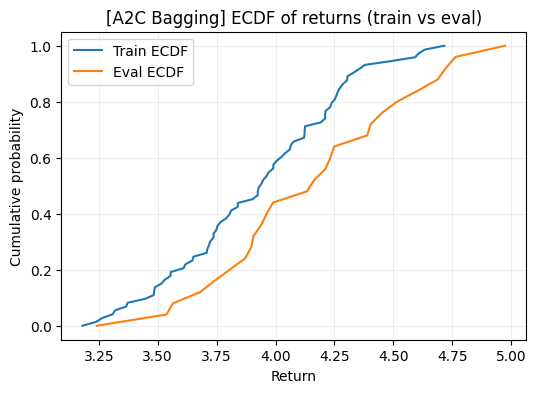

n_train=74  n_eval=26
mean_train=3.918  mean_eval=4.140  Δmean=+0.222
median_train=3.934 (IQR 0.545)   median_eval=4.149 (IQR 0.563)
p10/p90 train=3.457/4.324   p10/p90 eval=3.622/4.706
KS statistic=0.279   P(eval > train)=0.647   mean|ECDF gap|=0.124


In [19]:
ecdf = plot_ecdf_returns(a2c_dqn_metrics, title_prefix="[A2C Bagging] ")

The orange eval curve sits consistently to the right of the blue train curve, meaning that there are higher returns at almost every quantile. This is backed by the stats `mean_eval = 4.140` vs `mean_train = 3.918`. The KS distance equal to **0.279** indicates a clear, medium-sized stochastic dominance of eval over train, with no sign of overfitting. The ensembling model generalizes slightly better to eval. 

## 3. Residual Analysis

This graph detects under/overfitting in the critical area and bootstrap errors: high variance or systematic bias at the end of training. For RL it records TD errors $\delta_t=r_t+\gamma V(s_{t+1})-V(s_t)$ or the advantages $\hat A_t$ (GAE) during training.

This is important for our RL implementation as it diagnoses bias/variance of value estimation that drives policy updates.

In [20]:
def plot_residuals_rl(df, w=11, gamma=0.99, title_prefix=""):
    M = df.sort_values("episode").reset_index(drop=True)
    is_eval = (M["eval_mode"] == 1)

    # Choose best available residual signal
    if "value_s0" in M.columns:
        resid = M["return"] - M["value_s0"]
        resid_name = "return - V(s0)"
    else:
        baseline = rolling_mean(M["return"], w)
        resid = M["return"] - baseline
        resid_name = "return - rolling baseline"

    M = M.assign(resid=resid)

    fig, ax = plt.subplots(1,3, figsize=(15,4), constrained_layout=True)
    ax[0].plot(M["episode"], M["resid"]); ax[0].axhline(0, ls="--", color="gray")
    ax[0].set_title(f"{title_prefix}Residual over episodes"); ax[0].set_xlabel("Episode"); ax[0].set_ylabel(resid_name)

    ax[1].hist(M.loc[~is_eval,"resid"], bins=20, alpha=0.7, label="train")
    ax[1].hist(M.loc[ is_eval,"resid"], bins=20, alpha=0.7, label="eval")
    ax[1].set_title("Residual distribution (train vs eval)"); ax[1].legend()

    ax[2].scatter(M["steps"], M["resid"], s=14, alpha=0.6)
    ax[2].set_title("Residual vs steps"); ax[2].set_xlabel("Steps"); ax[2].set_ylabel(resid_name)
    plt.show()

    # Episode-level |resid| mean in eval, useful trend line
    ev = M[is_eval]
    if len(ev) >= 3:
        ep = ev["episode"].values
        y  = ev["resid"].abs().values
        m,b = np.polyfit(np.arange(len(y)), y, 1)
        print(f"Eval |residual| trend slope: {m:.6f}")

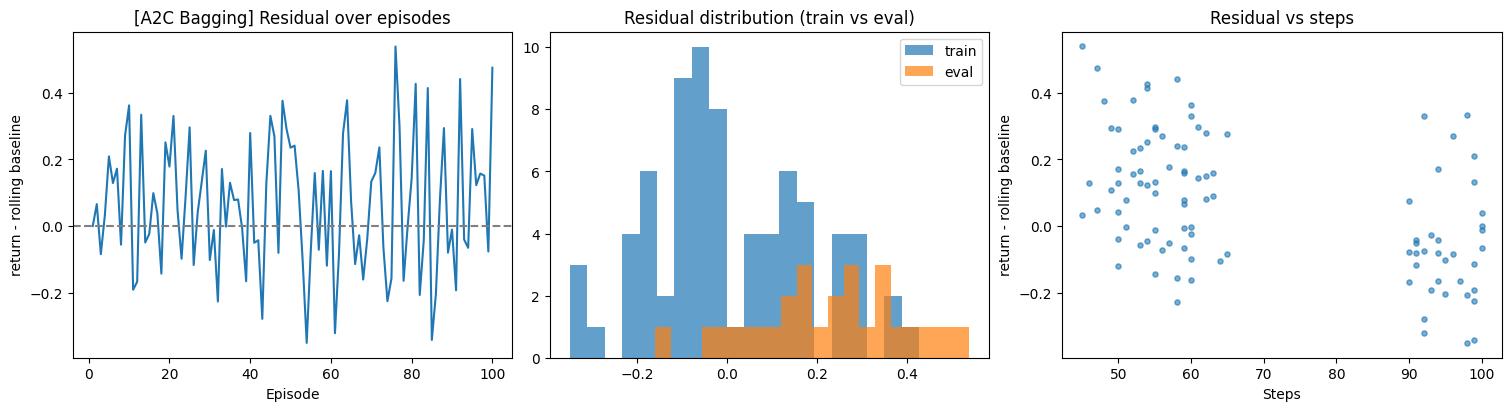

Eval |residual| trend slope: 0.007320


In [21]:
plot_residuals_rl(a2c_dqn_metrics, w=11, title_prefix="[A2C Bagging] ")

In the left panel, the eval residuals oscillate around zero without any clear drift. The reported slope of **0.007** suggests only a slight increase in variability late in training, not a trend. In the middle graph (histogram), eval residuals (orange) are shifted to the right, showing eval episodes generally outpetform their baseline more than train does (consistent with the positive eval-train gap). On the other hand, the right scatter shows only a weak relationship between steps and residuals: shorter/faster episodes (of about 50 to 70 steps) tend to have mildly positive residuals, while very long near-timeout episodes (90 to 100 steps, the maximum steps permitted) skew negative, which is expected. Overall, the residuals are centered, the variance is stable, and there is no sign of systematic under- or overfit by episode length.

## 4. Success vs Steps Trade-Off (Cycle-Time Quality)

This graph provides insight into whether successes finish well under the cap and how steps relate to outcomes.

This is important to tie task success to efficiency, matching the floor value of `median steps-to-success ≤ 80`. It also surfaces regressions where the agent wins but too slowly.

In [22]:
def plot_success_vs_steps(df, title_prefix=""):
    M = df[df["eval_mode"]==1].copy()  # focus on eval
    succ = M[M["success"]==1]["steps"].values
    fail = M[M["success"]==0]["steps"].values

    fig, ax = plt.subplots(1,2, figsize=(10,4), constrained_layout=True)

    # Scatter: steps vs return (color by success)
    ax[0].scatter(M["steps"], M["return"], c=M["success"],
                  cmap="coolwarm", alpha=0.7, s=25)
    ax[0].axvline(80, ls="--", color="gray", label="80-step floor")
    ax[0].set_xlabel("Steps"); ax[0].set_ylabel("Return")
    ax[0].set_title(f"{title_prefix}Eval: return vs steps (colored by success)")
    ax[0].legend()

    # Box/violin comparing steps for success vs fail
    ax[1].boxplot([succ, fail], tick_labels=["Success=1","Success=0"], showfliers=False)
    ax[1].axhline(80, ls="--", color="gray")
    ax[1].set_ylabel("Steps")
    ax[1].set_title("Steps distribution by outcome (eval only)")

    plt.show()

    if len(succ):
        print(f"Median steps (success eval): {np.median(succ):.1f}")
    if len(fail):
        print(f"Median steps (failure eval): {np.median(fail):.1f}")

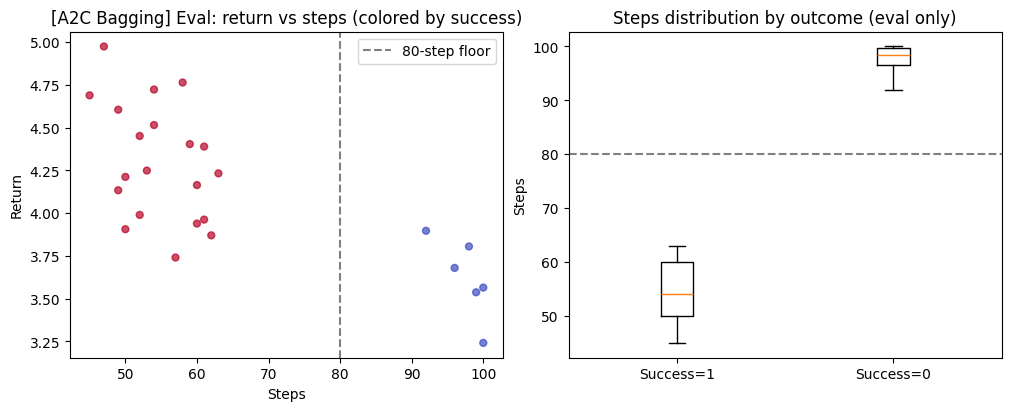

Median steps (success eval): 54.0
Median steps (failure eval): 98.5


In [23]:
plot_success_vs_steps(a2c_dqn_metrics, title_prefix="[A2C Bagging] ")

In the plot, we observe that the ensemble is winning quickly and failing only when it nearly times out. On the left, eval points lie mostly left of the 80-step line, and we can observe a clear negative relationship, where the higher returns happen at fewer steps. On the right graph, the boxplots are separated cleanly: successful evals finish with a median of ~54 steps, while failures cluster near the horizon with a median of ~98.5 steps. This separation means that success is not coming from long, meandering episodes, but is achieved efficiently and well under the `80-step floor`.

# References <a class="anchor" id="references" ></a>

[1] Tsinghua University, “History,” Tsinghua University. https://www.tsinghua.edu.cn/en/About/History.htm 

[2] Tsinghua University, “School of Vehicle and Mobility,” THU - Graduate Admissions. https://yz.tsinghua.edu.cn/en/info/1014/1115.htm 

[3] Instituto Nacional de Estadística y Geografía (INEGI), “Sistema de Clasificación Industrial de América del Norte, México SCIAN 2023,” INEGI, Jul. 28, 2023. https://www.inegi.org.mx/scian/ 

[4] Open Robotics, “Features and Benefits of GAZEBO SIM,” Gazebo. https://gazebosim.org/home 

[5] Open Robotics, “Getting started with ROS 2,” ROS 2 Documentation: Rolling Documentation. https://docs.ros.org/en/rolling/index.html 

[6] D. Ge and H. Ji, “Efficient Training in Multi-Agent Reinforcement Learning: A Communication-Free Framework for the Box-Pushing problem,” arXiv.org, Nov. 19, 2024. https://arxiv.org/abs/2411.12246 

[7] K. Kondo, C. T. Tewari, A. Tagliabue, J. Tordesillas, P. C. Lusk, and J. P. How, “PRIMER: Perception-Aware robust learning-based multiagent trajectory Planner,” arXiv (Cornell University), Jun. 2024, doi: 10.13140/rg.2.2.14435.57124. 

[8] H. Farivarnejad and S. Berman, “Multirobot control Strategies for collective transport,” Annual Review of Control Robotics and Autonomous Systems, vol. 5, no. 1, pp. 205–219, Nov. 2021, doi: 10.1146/annurev-control-042920-095844. 

[9] E. Elelimy, D. Szepesvari, M. White, and M. Bowling, “Rethinking the foundations for continual reinforcement learning,” arXiv.org, Apr. 10, 2025. https://arxiv.org/abs/2504.08161 

[10] C. Pan et al., “A survey of Continual Reinforcement learning,” arXiv.org, Jun. 27, 2025. https://arxiv.org/abs/2506.21872 

[11] M. Rahimi, S. Gibb, Y. Shen, and H. M. La, “A comparison of various approaches to reinforcement learning algorithms for multi-robot box pushing,” arXiv.org, Sep. 21, 2018. https://arxiv.org/abs/1809.08337 

[12] K. Javed and R. S. Sutton, “The Big World Hypothesis and its Ramifications for Artificial Intelligence,” OpenReview. https://openreview.net/forum?id=Sv7DazuCn8 

[13] S. Zhao, Mathematical foundations of reinforcement learning. 2025. doi: 10.1007/978-981-97-3944-8. 

[14] R. S. Sutton and A. G. Barto, Reinforcement learning: An Introduction. MIT Press, 1998. 

[15] S. E. Li, Reinforcement learning for sequential decision and optimal control. 2023. doi: 10.1007/978-981-19-7784-8. 

[16] J. Schulman, F. Wolski, P. Dhariwal, A. Radford, and O. Klimov, “Proximal Policy optimization Algorithms,” arXiv.org, Jul. 20, 2017. https://arxiv.org/abs/1707.06347

[17] T. Morimura, K. Ota, K. Abe, and P. Zhang, “Policy Gradient Algorithms with Monte Carlo Tree Learning for Non-Markov Decision Processes,” arXiv.org, Jun. 02, 2022. https://arxiv.org/abs/2206.01011

[18] “What is Deep Q-Network (DQN)?” https://milvus.io/ai-quick-reference/what-is-deep-qnetwork-dqn

[19] M. G. Bellemare, W. Dabney, and R. Munos, “A distributional perspective on Reinforcement learning,” arXiv.org, Jul. 21, 2017. https://arxiv.org/abs/1707.06887

[20] J. Murel and E. Kavlakoglu, “Ensemble learning,” IBM, Oct. 21, 2025. https://www.ibm.com/think/topics/ensemble-learning